In [1]:
import pandas as pd
from utils.plot_functions import get_tf_motif_seqs, prep_motif, prep_reps
import yaml
import logomaker as lm
import matplotlib.pyplot as plt

In [2]:
with open("../config/pipeline_config.yaml", "r") as f:
    config = yaml.safe_load(f)

main_dir = config["folders"]["main_dir"]
genome_dir = config["folders"]["genome_dir"]

tf_window_size = config["parameters"]["tf_window_size"]
damage_window = config["parameters"]["damage_formation_analysis_window"]

dhs_file = config["files"]["dhs_file"]

In [4]:
columns = ['pos', 'count', 'pred_mean', 'std_dev', 'pred_mean_scaled', 'std_dev_scal', 'pval', 'qval', 'enriched', 'zscore', 'zscore_scal', 'scal_factor_l', 'scal_factor_r', 'strand', 'TF']
cell_pvals = pd.read_csv(f'{main_dir}/results/analysis/damage_formation/tfs_top_{tf_window_size}_WT_CSB_6J_0hr_CPD_1bp_sorted_{dhs_file}_6mer_pvals_corrected_all.csv', header=None, names=columns)
nDNA_pvals = pd.read_csv(f'{main_dir}/results/analysis/damage_formation/tfs_top_{tf_window_size}_XPC_12J_NakedDNA_S22_CPD_1bp_sorted_{dhs_file}_6mer_pvals_corrected_all.csv', header=None, names=columns)

In [5]:
def plot_TFBS_damage_profile(tf, tf_len, std_n, wind_sz, cell_pvals, nDNA_pvals):

    tf_cell = cell_pvals[cell_pvals['TF']==tf]
    tf_nDNA = nDNA_pvals[nDNA_pvals['TF']==tf]
    tf_same, tf_opp = prep_reps(tf_cell, tf_nDNA, wind_sz)
    tf_same = tf_same.sort_values(by='pos')
    tf_opp = tf_opp.sort_values(by='pos')


    try:
        ic_matrix, rev_ic_matrix = prep_motif(f"{main_dir}/results/TFBS/{tf}_top_20_seqs")
    except:
        get_tf_motif_seqs(tf, f"{tf}_top_100_seq", tf_window_size, f"{main_dir}/results/TFBS", genome_dir)
        ic_matrix, rev_ic_matrix = prep_motif(f"{main_dir}/results/TFBS/{tf}_top_20_seqs")


    plot_same_txt = "Motif strand"
    plot_opp_txt = "Complement strand"

    plt.rcParams['font.family'] = 'Helvetica'
    fig, axes = plt.subplots(nrows=3, ncols=1, gridspec_kw={'height_ratios': [5, 2,1.25]}, figsize=(12, 10), sharex=True)

    for i in range(-(tf_len//2), tf_len//2+1):
        axes[0].axvline(x=i, color='black', linestyle='--', linewidth=.5, alpha=0.5, zorder=0)
        axes[1].axvline(x=i, color='black', linestyle='--', linewidth=.5, alpha=0.5, zorder=0)
        axes[2].axvline(x=i, color='black', linestyle='--', linewidth=.5, alpha=0.5, zorder=0)

    # Top line plot of BPDE signal across window
    axes[0].plot(tf_same['pos'], tf_same['count'], label=plot_same_txt, color='mediumseagreen', marker='o', linestyle='-', alpha=0.8, linewidth=1.5)
    axes[0].plot(tf_opp['pos'], tf_opp['count'], label=plot_opp_txt, color='magenta', marker='o', linestyle='-', alpha=0.8, linewidth=1.5)
    axes[0].fill_between(tf_same['pos'],
                     tf_same["pred_mean_scaled"] + (tf_same['std_dev_scal'] * std_n),
                     tf_same["pred_mean_scaled"] - (tf_same['std_dev_scal'] * std_n),
                     color='grey', alpha=0.3, linewidth=0)
    axes[0].fill_between(tf_opp['pos'],
                     tf_opp["pred_mean_scaled"] + (tf_opp['std_dev_scal'] * std_n),
                     tf_opp["pred_mean_scaled"] - (tf_opp['std_dev_scal'] * std_n),
                     color='grey', alpha=0.3, linewidth=0)
    axes[0].grid(False)
    axes[0].tick_params(axis='y', which='major', labelsize=30)
    axes[0].set_ylabel(f"CPD counts", fontsize=35)


    # Middle scatter plot of q-values
    axes[1].scatter(tf_same[tf_same['FDR']==False]["pos"], tf_same[tf_same['FDR']==False][f'qval_log'], label=plot_same_txt, color='black', linewidth=0, s=65)

    axes[1].scatter(tf_same[(tf_same['FDR']==True)&(tf_same['enriched_cell']==True)]["pos"], tf_same[(tf_same['FDR']==True)&(tf_same['enriched_cell']==True)][f'zscore_scal_cell'], label=plot_same_txt, color='mediumseagreen', alpha=0.9, marker="^", s=150, edgecolor='darkgreen', linewidth=.5)
    axes[1].scatter(tf_same[(tf_same['FDR']==True)&(tf_same['enriched_cell']==False)]["pos"], tf_same[(tf_same['FDR']==True)&(tf_same['enriched_cell']==False)][f'zscore_scal_cell'], label=plot_same_txt, color='mediumseagreen', alpha=.9, marker="v", s=150, edgecolor='darkgreen', linewidth=.5)

    axes[1].scatter(tf_opp[tf_opp['FDR']==False]["pos"], tf_opp[tf_opp['FDR']==False][f'qval_log'], label=plot_opp_txt, color='black', linewidth=0, s=65)

    axes[1].scatter(tf_opp[(tf_opp['FDR']==True)&(tf_opp['enriched_cell']==True)]["pos"], tf_opp[(tf_opp['FDR']==True)&(tf_opp['enriched_cell']==True)][f'zscore_scal_cell'], label=plot_opp_txt, color='magenta', alpha=0.9, marker="^", s=150, edgecolor='purple', linewidth=.5)
    axes[1].scatter(tf_opp[(tf_opp['FDR']==True)&(tf_opp['enriched_cell']==False)]["pos"], tf_opp[(tf_opp['FDR']==True)&(tf_opp['enriched_cell']==False)][f'zscore_scal_cell'], label=plot_opp_txt, color='magenta', alpha=0.9, marker="v", s=150, edgecolor='purple', linewidth=.5)

    min_zscore = round(min(tf_opp['zscore_scal_cell'].min(), tf_same['zscore_scal_cell'].min())) - 5
    max_zscore = round(max(tf_opp['zscore_scal_cell'].max(), tf_same['zscore_scal_cell'].max())) + 5

    axes[1].grid(color='dimgray', axis='x', linestyle='--', linewidth=.5)
    axes[1].grid(axis='x', which='both', linestyle='')
    axes[1].set_ylabel("")
    axes[1].tick_params(axis='y', which='major', labelsize=25)
    axes[1].set_ylabel("")
    axes[1].set_ylim([min_zscore, max_zscore])
    axes[1].set_ylabel(f"z-score", fontsize=30)


    lm.Logo(ic_matrix, shade_below=.5, fade_below=.5, ax=axes[2])
    # Plot the reverse complement on the negative y-axis
    lm.Logo(rev_ic_matrix, shade_below=.5, fade_below=.5, color_scheme='classic', ax=axes[2])
    ax3_ymin, ax3_ymax = axes[2].get_ylim()
    axes[2].set_ylim(min(ax3_ymin, rev_ic_matrix.min().min()), max(ax3_ymax, ic_matrix.max().max()))

    axes[2].yaxis.tick_right()
    axes[2].yaxis.set_label_position("right")
    axes[2].grid(False)
    axes[2].set_yticks([])
    axes[2].set_xticks([])
    axes[2].tick_params(axis='x', which='major', labelsize=30)
    axes[2].set_ylim([-2, 2])
    axes[2].set_xlabel(f"Position relative to TF motif center", fontsize=35)



# X-axis format
    axes[1].xaxis.set_major_locator(plt.MultipleLocator(5))
    for ax in axes.flat:
        ax.spines['top'].set_color('None')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.spines['left'].set_linewidth(.5)
        ax.spines['right'].set_color('None')
        ax.spines['right'].set_linewidth(.5)
    axes[0].spines['bottom'].set_color('black')
    axes[0].spines['bottom'].set_linewidth(.5)
    axes[1].spines['bottom'].set_linewidth(.5)
    axes[2].spines['left'].set_color('None')
    axes[2].spines['bottom'].set_color('None')

    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    gray_shading_patch = mpatches.Patch(color='grey', alpha=0.3, label=f'+/- {std_n} SD')
    black_dot = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Non-significant')
    triangle = mlines.Line2D([], [], color='magenta', marker='^', markeredgecolor='purple', markeredgewidth=1, markersize=10, label='p-value < 0.05', linestyle='None')
    # Legend format
    axes[0].legend(loc='upper right', prop={'size':15}, framealpha=1, handles=[*axes[0].get_legend_handles_labels()[0],gray_shading_patch, black_dot, triangle])

    fig.suptitle(f"{tf.replace('_','/')}", fontsize=40)
    plt.xlim(-wind_sz, wind_sz)
    plt.tight_layout()

In [6]:
#Example TF
tf = 'ETS_1'
tf_len = 10
std_n = 4
wind_sz = 10

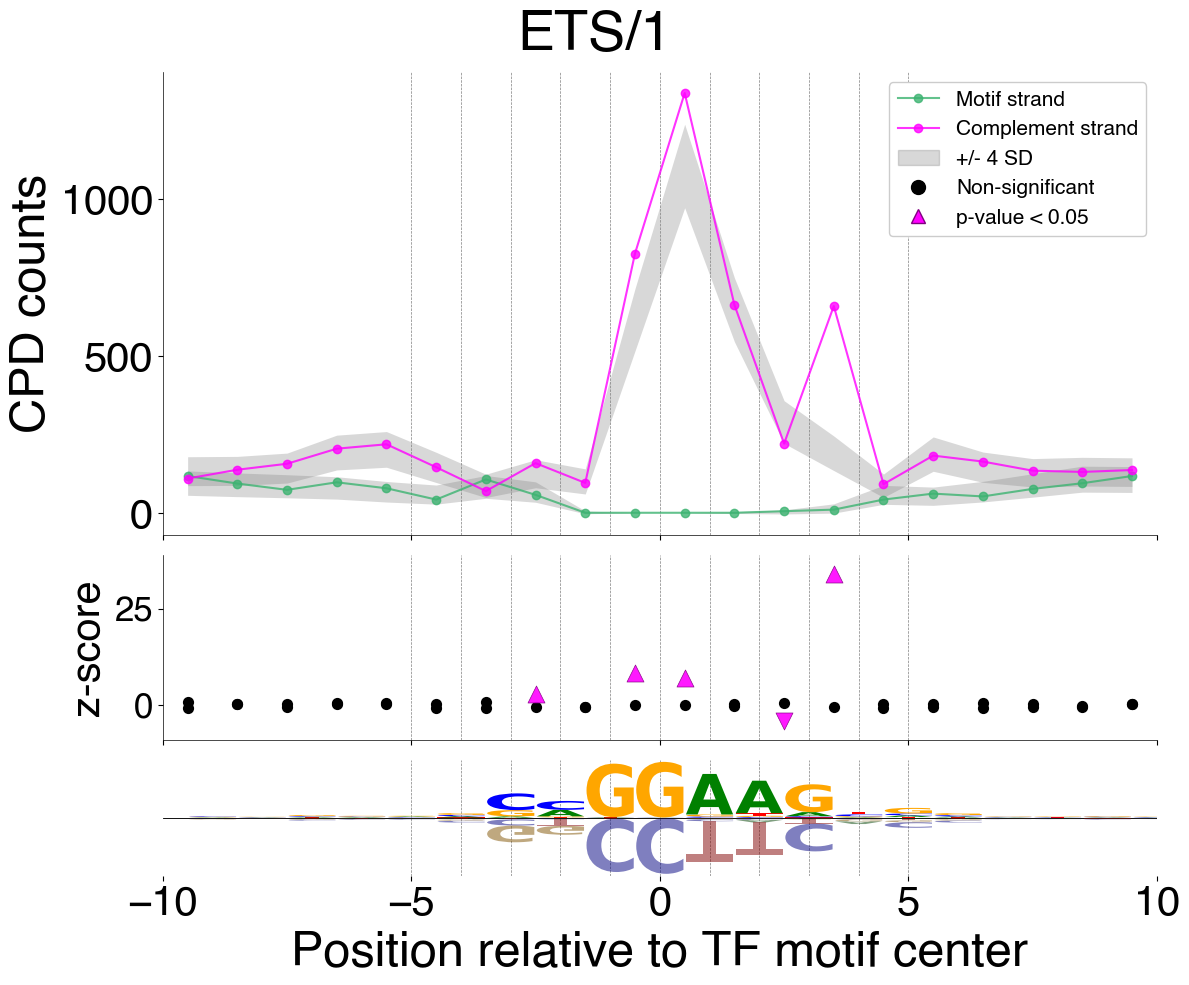

In [8]:
plot_TFBS_damage_profile(tf, tf_len, std_n, wind_sz, cell_pvals, nDNA_pvals)